In [34]:
import torch 
import torch.nn as nn
import numpy as np 
from datasets import load_dataset
from tqdm import tqdm 
import yaml 
from pathlib import Path
import os 
torch.set_float32_matmul_precision('medium')
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

from IPython.display import Audio
import importlib

import robustness.audio_functions.audio_transforms as at 
from lightning_scripts.lightning_ssl_matched_speech_in_noise import LitAudioSSL

from lightning_scripts.lightning_classifier_matched_speech_in_noise import (
    LitWordAudioSetModel
)


%matplotlib inline
import matplotlib.pyplot as plt

## Import models

In [2]:
# Device and target sample rate for generated clips
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_SR = 20_000

# Load 6 pretrained models
import importlib
from lightning_scripts.utils import model_build_utils
importlib.reload(model_build_utils)
from lightning_scripts.utils.model_build_utils import get_model

ssl_lambda_0_config = Path("model_configs/kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_0e-01_audioset_only.yaml")
ssl_lambda_5_config = Path("model_configs/kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_5e-01_audioset_only.yaml")
word_config = Path("model_configs/supervised_models/word_kell2018_MatchedDataset_LARS.yaml")
audioset_config = Path("model_configs/supervised_models/audioset_kell2018_MatchedDataset_LARS.yaml")
multitask_config = Path("model_configs/supervised_models/kell2018_word_speaker_audioset_MatchedDataset_LARS.yaml")
unbal_audioset_config = Path("model_configs/supervised_models/kell2018_audioset_unbalanced_supervised.yaml")

models = {
    "ssl_lambda_0": get_model(ssl_lambda_0_config, layer_out="relu4"),
    "ssl_lambda_5": get_model(ssl_lambda_5_config, layer_out="relu4"),
    "word": get_model(word_config, supervised=True, layer_out="relu4"),
    "audioset": get_model(audioset_config, supervised=True, layer_out="relu4"),
    "multitask": get_model(multitask_config, supervised=True, layer_out="relu4"),
    "unbal_audioset": get_model(unbal_audioset_config, supervised=True, layer_out="relu4"),
}

for m in models.values():
    m.eval().to(DEVICE)

print(f"Loaded {len(models)} models on {DEVICE}")


Loaded 6 models on cuda


# Get the dataset 

In [3]:
speech_commands = load_dataset("google/speech_commands", 'v0.01')

README.md: 0.00B [00:00, ?B/s]

speech_commands.py: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/51093 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/6799 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3081 [00:00<?, ? examples/s]

In [4]:
train_split = speech_commands['train']
# remove silence 
train_split = train_split.filter(lambda example: (not ('_silence_' in example['file'])) and (not (example['audio']['array'] is None)))
train_split = train_split.shuffle(seed=1)
val_split = speech_commands['validation']
test_split = speech_commands['test']

Filter:   0%|          | 0/51093 [00:00<?, ? examples/s]

In [47]:
class TripletDataset(torch.utils.data.Dataset):
    """
    PyTorch Dataset for creating triplets from speech_commands dataset.
    
    Each triplet contains:
    1. Word 1 before Word 2 (concatenated) - pair12
    2. Time-shifted version of pair12, shifted forward by 250ms - pair12_shifted
    3. Word 2 before Word 1 (concatenated) - pair21
    
    Both examples are guaranteed to be of the same word.
    """
    
    def __init__(self, dataset_split, seed=None, shift_samples=5000):
        """
        Args:
            dataset_split: HuggingFace dataset split (train/val/test)
            seed: Random seed for reproducibility
            shift_samples: Number of samples to shift forward (default: 5000 = 250ms at 20kHz)
        """
        self.dataset_split = dataset_split
        self.shift_samples = shift_samples
        
        # Group examples by label
        examples_by_label = {}
        for idx, example in enumerate(dataset_split):
            label = example['label']
            if label not in examples_by_label:
                examples_by_label[label] = []
            examples_by_label[label].append(idx)
        
        # Filter out labels with fewer than 2 examples
        self.valid_labels = {label: indices for label, indices in examples_by_label.items() 
                            if len(indices) >= 2}
        
        # Create a list of all valid triplet pairs (label, idx1, idx2)
        # We pre-generate pairs to ensure deterministic length
        self.triplet_pairs = []
        for label, indices in self.valid_labels.items():
            # For each label, create pairs of indices
            for i in range(len(indices)):
                for j in range(i + 1, len(indices)):
                    self.triplet_pairs.append((label, indices[i], indices[j]))
        
        # Set random seed if provided
        if seed is not None:
            np.random.seed(seed)
            torch.manual_seed(seed)
    
    def __len__(self):
        return len(self.triplet_pairs)
    
    def __getitem__(self, idx):
        """
        Returns a tuple of 3 tensors: (pair12, pair12_shifted, pair21)
        """
        label, idx1, idx2 = self.triplet_pairs[idx]
        
        # Get the audio arrays
        example1 = self.dataset_split[idx1]
        example2 = self.dataset_split[idx2]
        
        audio1 = example1['audio']['array']
        audio2 = example2['audio']['array']
        
        padding =  torch.zeros(self.shift_samples)

        # Create pair12: word1 followed by word2
        pair12 = torch.from_numpy(np.concatenate([audio1, padding , audio2])).float()
        
        # Create pair12_shifted: shift pair12 forward by 250ms (pad zeros at beginning)
        pair12_shifted = torch.cat([
            torch.zeros(self.shift_samples),
            pair12
        ])
        # Crop to same length as pair12 (remove from end)
        pair12_shifted = pair12_shifted[:len(pair12)]
        
        # Create pair21: word2 followed by word1
        pair21 = torch.from_numpy(np.concatenate([audio2, padding, audio1])).float()
        
        return pair12, pair12_shifted, pair21


# Create dataset (dataloader will be created with collate function in next cell)
triplet_dataset = TripletDataset(train_split, seed=42)


## Eval loop logic

In [48]:
from torchaudio.transforms import Resample
resamp = Resample(16_000, 20_000)

In [49]:
ix = 0 
batch_size = 10 
start = ix * batch_size 
end = start + batch_size 
batch = train_split[start:end]


crop_or_pad = at.CenterCropOrPad(40000)
db_spl = 60 
set_dbSPL = at.DBSPLNormalizeForegroundAndBackground(db_spl)

def process_batch(batch):
    audio = batch['audio']
    word_int_label = torch.tensor(batch['label']).cuda()
    label_ixs = []
    tformed_audio = []
    for ix, eg in enumerate(audio):
        wav = torch.from_numpy(eg['array'])
        # wav, _ = audio_transforms(eg['array'], None)
        wav = resamp(wav.float())
        # zero pad word to middle of frame 
        wav = crop_or_pad(wav.squeeze())
        wav, _ = set_dbSPL(wav, None)
        if wav is None:
            continue
        tformed_audio.append(wav.unsqueeze(0))
        label_ixs.append(ix)
    audio = torch.stack(tformed_audio).cuda()
    word_int_label = word_int_label[label_ixs]
    return audio, word_int_label

audio, labels = process_batch(batch)

In [50]:
def triplet_collate_fn(batch):
    """
    Collate function for triplet dataset that applies transforms during batching.
    
    Args:
        batch: List of tuples, where each tuple is (pair12, pair12_shifted, pair21) 
               from the dataset's __getitem__ method
    
    Returns:
        Tuple of 3 processed tensors: (pair12_processed, pair12_shifted_processed, pair21_processed)
        All tensors are on CUDA and have consistent shapes within each type.
    """
    # Unpack the batch into separate lists
    pair12_list, pair12_shifted_list, pair21_list = zip(*batch)
    
    # Process pairs
    crop_or_pad_pair = at.CenterCropOrPad(40000)  # 2 seconds at 20kHz 
    tformed_pair12 = []
    tformed_pair12_shifted = []
    tformed_pair21 = []
    
    for p12, p12_shifted, p21 in zip(pair12_list, pair12_shifted_list, pair21_list):
        # Process pair12
        wav12 = resamp(p12.float())
        wav12 = crop_or_pad_pair(wav12.squeeze())
        wav12, _ = set_dbSPL(wav12, None)
        if wav12 is None:
            continue
        
        # Process pair12_shifted
        wav12_shifted = resamp(p12_shifted.float())
        wav12_shifted = crop_or_pad_pair(wav12_shifted.squeeze())
        wav12_shifted, _ = set_dbSPL(wav12_shifted, None)
        if wav12_shifted is None:
            continue
        
        # Process pair21
        wav21 = resamp(p21.float())
        wav21 = crop_or_pad_pair(wav21.squeeze())
        wav21, _ = set_dbSPL(wav21, None)
        if wav21 is None:
            continue
        
        # Only add if all three succeeded
        tformed_pair12.append(wav12.unsqueeze(0))
        tformed_pair12_shifted.append(wav12_shifted.unsqueeze(0))
        tformed_pair21.append(wav21.unsqueeze(0))
    
    # Stack and move to CUDA
    pair12_processed = torch.stack(tformed_pair12).cuda()
    pair12_shifted_processed = torch.stack(tformed_pair12_shifted).cuda()
    pair21_processed = torch.stack(tformed_pair21).cuda()
    
    return pair12_processed, pair12_shifted_processed, pair21_processed


# Create dataloader with collate function
triplet_dataloader = torch.utils.data.DataLoader(
    triplet_dataset, 
    batch_size=256, 
    shuffle=True,
    collate_fn=triplet_collate_fn,
    num_workers=0  # Set to >0 if you want parallel loading
)

# Test it out
for pair12, pair12_shifted, pair21 in triplet_dataloader:
    print(f"Processed batch shapes:")
    print(f"  pair12: {pair12.shape}")
    print(f"  pair12_shifted: {pair12_shifted.shape}")
    print(f"  pair21: {pair21.shape}")
    break


Processed batch shapes:
  pair12: torch.Size([256, 1, 40000])
  pair12_shifted: torch.Size([256, 1, 40000])
  pair21: torch.Size([256, 1, 40000])


In [51]:
from IPython.display import Audio, display 

In [52]:
display(Audio(pair12[0].cpu(), rate=20_000))
display(Audio(pair12_shifted[0].cpu(), rate=20_000))
display(Audio(pair21[0].cpu(), rate=20_000))

In [53]:
import torch.nn.functional as F
import pandas as pd

def encode_audio(model, audio_batch: torch.Tensor) -> torch.Tensor:
    model.eval()
    with torch.no_grad():
        z = model(audio_batch)
        if z.ndim > 2:
            z = z.flatten(start_dim=1)
    return z


def process_triplet(model, pair12, pair12_shifted, pair21):
    z_pair12 = encode_audio(model, pair12)
    z_pair12_shifted = encode_audio(model, pair12_shifted)
    z_pair21 = encode_audio(model, pair21)
    pos_l2 = torch.norm(z_pair12 - z_pair12_shifted, dim=1, p=2)
    neg_l2 =  torch.norm(z_pair12 - z_pair21, dim=1, p=2)
    judgement = pos_l2 < neg_l2
    return judgement



def print_losses(loss):
    # Print all losses
    print(f"Word order discrimination (pair12, pair12_shifted+, pair21-): {loss.mean():.4f} (+/-{loss.std().item():.4f})")

# Load 4 batches from the dataloader
pair12_batches = []
pair12_shifted_batches = []
pair21_batches = []

for i, (p12, p12_shifted, p21) in enumerate(triplet_dataloader):
    pair12_batches.append(p12)
    pair12_shifted_batches.append(p12_shifted)
    pair21_batches.append(p21)
    if i >= 3:  # Process 4 batches (0, 1, 2, 3)
        break

print(f"Processing {len(pair12_batches)} batches")

# Cache all judgements for each model
model_judgements = {}
for model_name, model in models.items():
    print(f"Processing {model_name} model")
    all_judgements = []
    for p12, p12_shifted, p21 in zip(pair12_batches, pair12_shifted_batches, pair21_batches):
        batch_judgements = process_triplet(model, p12, p12_shifted, p21)
        all_judgements.append(batch_judgements)
    # Concatenate all batch judgements
    all_judgements = torch.cat(all_judgements, dim=0)
    model_judgements[model_name] = all_judgements

# Compute mean and std over all batches for each model
model_losses = []
for model_name, judgements in model_judgements.items():
    mean_judgement = judgements.float().mean().item()
    std_judgement = judgements.float().std().item() / np.sqrt(len(judgements))
    model_record = {
        "model": model_name,
        "mean_judgement": mean_judgement,
        "std_judgement": std_judgement
    }
    model_losses.append(model_record)
    
judgement_df = pd.DataFrame(model_losses)


Processing 4 batches
Processing ssl_lambda_0 model
Processing ssl_lambda_5 model
Processing word model
Processing audioset model
Processing multitask model
Processing unbal_audioset model


In [54]:
judgement_df 


,model,mean_judgement,std_judgement
0,ssl_lambda_0,0.198242,0.012465
1,ssl_lambda_5,0.199219,0.012488
2,word,0.369141,0.015088
3,audioset,0.790039,0.012734
4,multitask,0.263672,0.013776
5,unbal_audioset,0.191406,0.012300


In [55]:
## Init common colors and plot names 

palette = {
    "multitask": "grey",
    "audioset": "orange",
    "unbal_audioset": "red",
    "word": "blue",
    "ssl_lambda_0": "olive",
    "ssl_lambda_5": "gold",
}


model_labels = [
    "jsin multi-task supervised",
    "unbalanced audioset supervised",
    "jsin audioset supervised",
    "jsin word supervised",
    "unbal. audioset ssl $\\lambda=0$",
    "unbal. audioset ssl $\\lambda=0.5$",
]

model_name_dict = {
    "multitask": "jsin multi-task supervised",
    "unbal_audioset": "unbalanced audioset supervised",
    "audioset": "jsin audioset supervised",
    "word": "jsin word supervised",
    "ssl_lambda_0": "unbal. audioset ssl $\\lambda=0$",
    "ssl_lambda_5": "unbal. audioset ssl $\\lambda=0.5$",
}

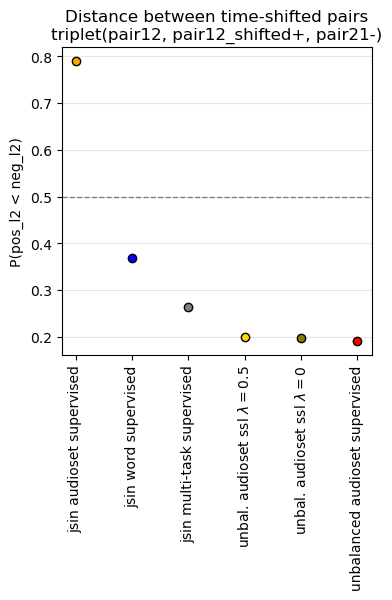

In [56]:
# judgement_rate = judgement_df.groupby("model")["mean_judgement"]
# sort by judgement rate
judgement_rate = judgement_df.sort_values("mean_judgement", ascending=False)

fig, axes = plt.subplots(1, 1, figsize=(4, 4))
models_order = judgement_rate.model

for i, model in enumerate(models_order):

    mean_loss = judgement_df[judgement_df.model == model]["mean_judgement"].mean()
    error = 2 * judgement_df[judgement_df.model == model]["mean_judgement"].std() / np.sqrt(len(judgement_df[judgement_df.model == model]))
    axes.errorbar(
        [i],
        [mean_loss],
        fmt='o',
        yerr=error,
        label=model,
        color=palette[model],
        markeredgecolor="k",
    )

xtick_labels = [model_name_dict[model] for model in models_order]

axes.set_xticks(range(len(xtick_labels)))
axes.set_xticklabels(xtick_labels, rotation=90, ha='center')
# axes.set_yticks(np.linspace(0, 1, 5))
# axes.set_ylim(0.5, 1)
axes.axhline(0.5, color='gray', linestyle='--', linewidth=1)
axes.set_ylabel("P(pos_l2 < neg_l2)")
axes.set_title("Distance between time-shifted pairs\ntriplet(pair12, pair12_shifted+, pair21-)")
axes.grid(True, axis="y", alpha=0.3)
plt.show()